In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu


num_experts = 6, top_k = 4, samples = 13627


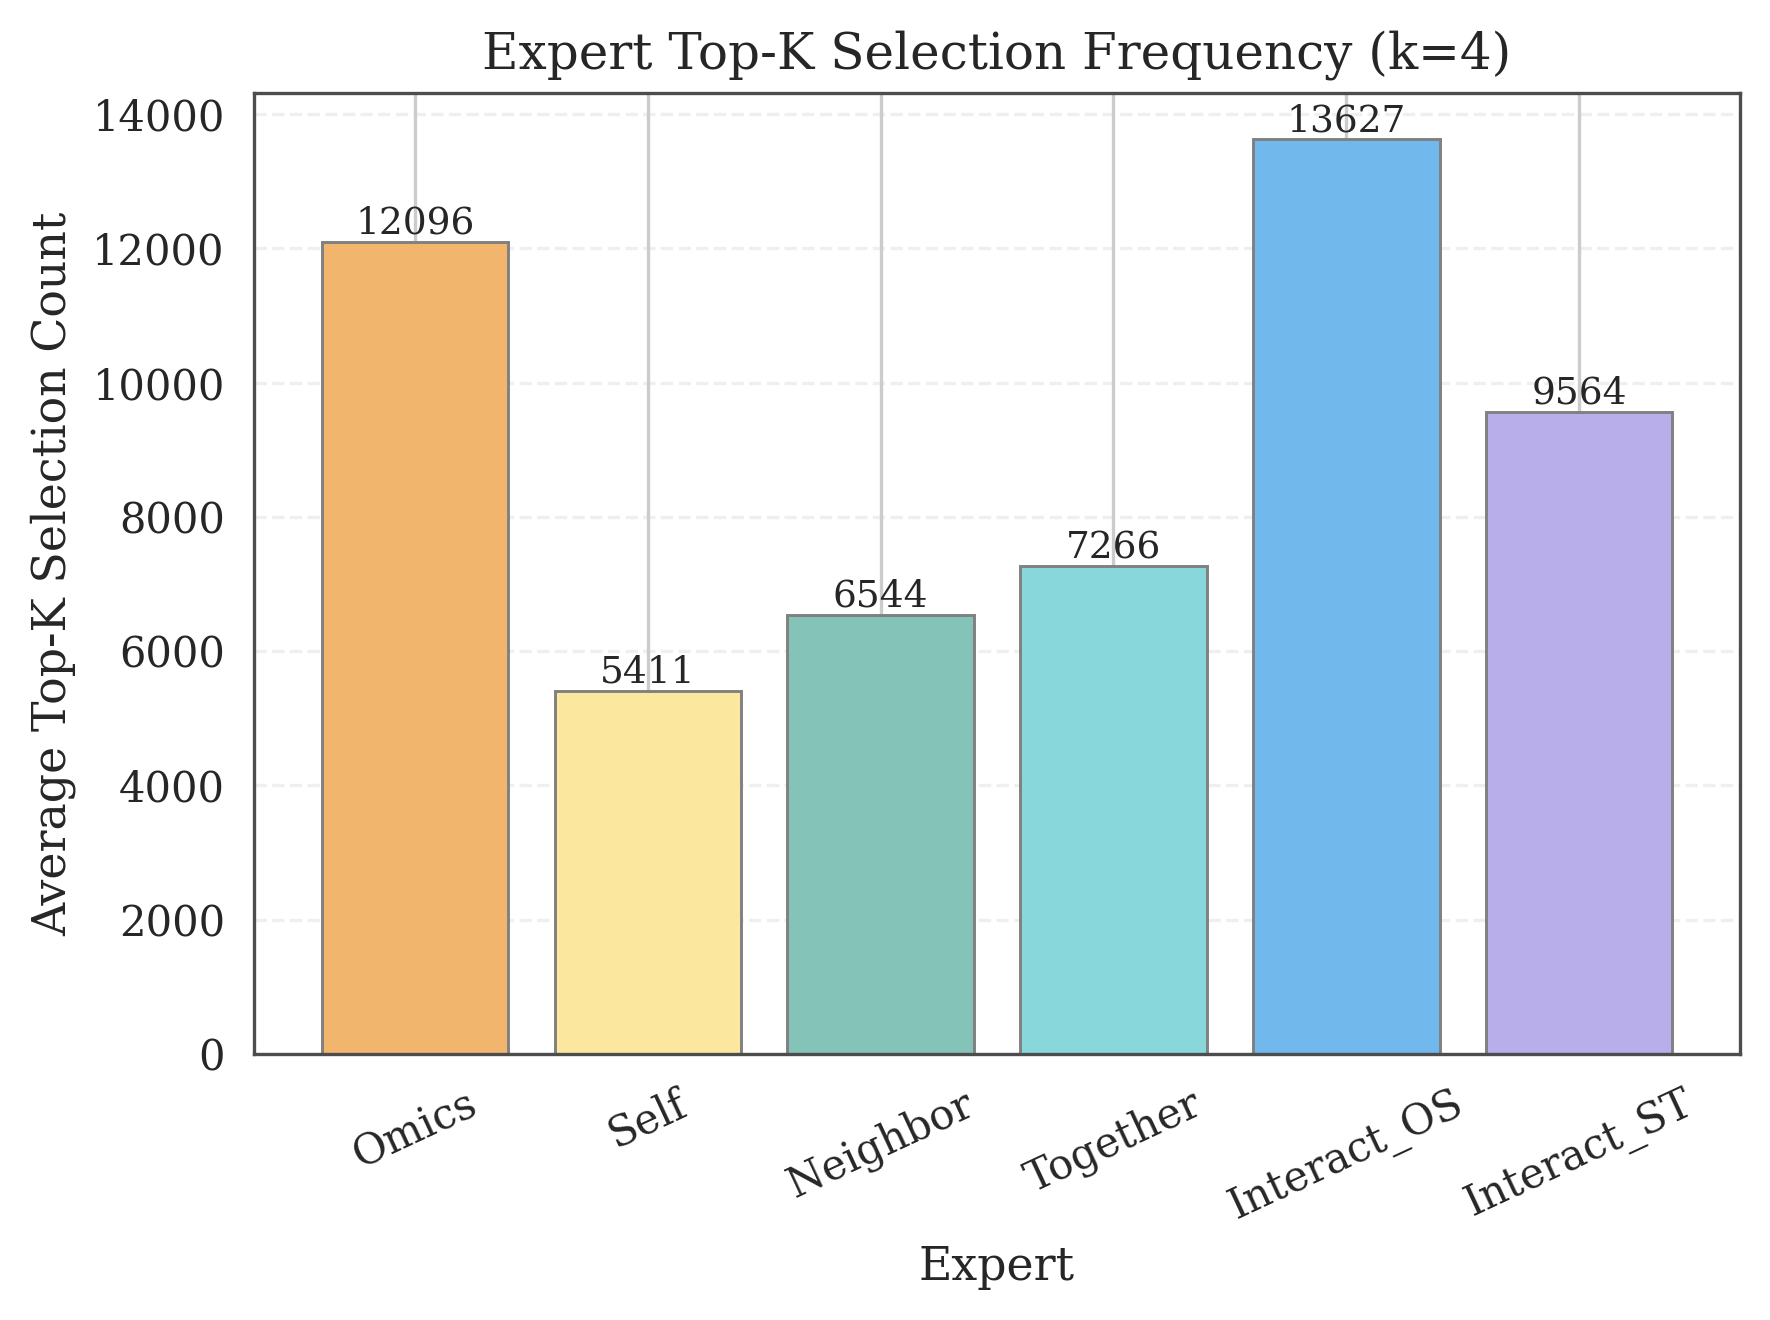

In [11]:
# 初始化列表存储所有实验结果
all_gating_scores = []
all_topk_counts = []

expert_names = ["Omics", "Self", "Neighbor", "Together", "Interact_OS", "Interact_ST"]

# 定义SCI学术风格的浅色配色方案
sci_colors = ['#f2b56e', '#fbe79e', '#84c3b7', '#88d7da', '#71b8ed', '#b8aeea']

# 设置全局绘图参数
plt.rcParams.update({
    'font.family': 'serif',  # 学术论文常用衬线字体
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'png',
    'savefig.bbox': 'tight',
    'axes.edgecolor': '0.3',
    'axes.linewidth': 0.8,
})

# 加载1-5号文件并收集数据
for i in range(1, 6):
    file_path = f"results/gating_analysis/参数分析gating_activation{i}.pt"
    ckpt = torch.load(file_path)
    
    # 获取当前实验数据
    gating_score = ckpt['gating_score'].numpy()   # [N, num_experts]
    topk_indices = ckpt['topk_indices'].numpy()   # [N, k]
    
    # 检查专家数量是否一致
    num_experts = gating_score.shape[1]
    assert num_experts == len(expert_names), f"文件{i}中专家数({num_experts})与命名列表({len(expert_names)})不一致"
    
    # 统计当前实验的top-k选择次数
    counts = np.bincount(topk_indices.flatten(), minlength=num_experts)
    all_topk_counts.append(counts)
    all_gating_scores.append(gating_score)

    # 第一次迭代时获取top-k值
    if i == 1:
        topks = topk_indices.shape[1]
        sample_shape = gating_score.shape[0]
        print(f"num_experts = {num_experts}, top_k = {topks}, samples = {sample_shape}")

# 计算平均结果
avg_topk_counts = np.mean(all_topk_counts, axis=0)  # 平均选择次数
avg_gating_scores = np.mean(np.array(all_gating_scores), axis=0)  # 平均门控分数

x = np.arange(num_experts)

# 1) Top-k 专家被选中的平均频率
plt.figure(figsize=(6, 4.5))
bars = plt.bar(x, avg_topk_counts, color=sci_colors, edgecolor='gray', linewidth=0.7)

# 在柱子上显示平均频数（保留整数）
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, 
             f"{int(round(height))}", ha="center", va="bottom", fontsize=9)

plt.xticks(x, expert_names, rotation=25)
plt.xlabel("Expert", fontweight='medium')
plt.ylabel("Average Top-K Selection Count", fontweight='medium')
plt.title(f"Expert Top-K Selection Frequency (k={topks})", fontweight='medium')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("topk_frequency_avg.png")
plt.show()


# # 2) 平均gating score的分布（箱线图）
# plt.figure(figsize=(6, 4.5))
# boxprops = dict(facecolor='none', edgecolor='gray', linewidth=0.8)
# medianprops = dict(color='#d62728', linewidth=1.5)
# whiskerprops = dict(color='gray', linewidth=0.8)
# capprops = dict(color='gray', linewidth=0.8)

# boxplot = plt.boxplot([avg_gating_scores[:, i] for i in range(num_experts)], 
#                       labels=expert_names,
#                       patch_artist=True,
#                       boxprops=boxprops,
#                       medianprops=medianprops,
#                       whiskerprops=whiskerprops,
#                       capprops=capprops)

# # 为每个箱体设置填充色
# for patch, color in zip(boxplot['boxes'], sci_colors):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.7)  # 添加透明度使颜色更柔和

# plt.xlabel("Expert", fontweight='medium')
# plt.ylabel("Average Gating Score", fontweight='medium')
# plt.title("Distribution of Average Gating Scores per Expert", fontweight='medium')
# plt.grid(axis='y', linestyle='--', alpha=0.3)
# plt.tight_layout()
# plt.savefig("gating_score_distribution_avg.png")
# plt.show()

# # 3) 第一个样本的5次实验平均gating分数条形图
# sample_id = 0
# plt.figure(figsize=(6, 4.5))
# bars = plt.bar(x, avg_gating_scores[sample_id], color=sci_colors, edgecolor='gray', linewidth=0.7)

# # 添加数值标签
# for i, bar in enumerate(bars):
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, height/2, 
#              f"{height:.2f}", ha="center", va="center", 
#              color='black', fontsize=9, fontweight='medium')

# plt.xticks(x, expert_names, rotation=25)
# plt.xlabel("Expert", fontweight='medium')
# plt.ylabel("Average Score", fontweight='medium')
# plt.title(f"Average Gating Scores for Sample {sample_id} (over 5 runs)", fontweight='medium')
# plt.grid(axis='y', linestyle='--', alpha=0.3)
# plt.tight_layout()
# plt.savefig("sample0_gating_avg.png")
# plt.show()

In [21]:
# 计算平均结果
avg_drive_counts = np.mean(all_drive_counts, axis=0)  # 驱动基因平均选择次数
avg_non_drive_counts = np.mean(all_non_drive_counts, axis=0)  # 非驱动基因平均选择次数
total_counts = avg_drive_counts + avg_non_drive_counts

# 1) Top-k 专家被选中的平均频率（按基因类型分类）
plt.figure(figsize=(15, 10))

# 创建堆叠柱状图（使用浅色系配色，调整柱状图宽度）
width = 0.6  # 减小柱状图宽度
bars_drive = plt.bar(x, avg_drive_counts, width=width, color='#a6cee3', edgecolor='#1f78b4', linewidth=1, label='Driver Genes')
bars_non_drive = plt.bar(x, avg_non_drive_counts, width=width, bottom=avg_drive_counts, 
                         color='#fdbf6f', edgecolor='#ff7f00', linewidth=1, label='Non-Driver Genes')

# 在柱子上显示总频数（保留整数，增大字体）
for i, (drive, non_drive) in enumerate(zip(avg_drive_counts, avg_non_drive_counts)):
    total = drive + non_drive
    plt.text(x[i], total + 1, f"{int(round(total))}", ha="center", va="bottom", fontsize=11, color='#333333', fontweight='bold')

# 添加部分标签（增大字体）
for i, (drive, non_drive) in enumerate(zip(avg_drive_counts, avg_non_drive_counts)):
    # 驱动基因标签（底部）
    if drive > 0:
        plt.text(x[i], drive/2, f"{int(round(drive))}", ha="center", va="center", fontsize=10, fontweight='bold')
        print(f"{expert_names[i]}: Driver Genes = {int(round(drive))}")
    
    # 非驱动基因标签（顶部）
    if non_drive > 0:
        plt.text(x[i], drive + non_drive/2, f"{int(round(non_drive))}", ha="center", va="center", fontsize=10, fontweight='bold')
        print(f"{expert_names[i]}: Non-Driver Genes = {int(round(non_drive))}")
plt.xticks(x, expert_names, fontsize=12, fontweight='bold')
# plt.xlabel("Expert", fontweight='bold')
plt.ylabel("Selection Count", fontweight='medium', fontsize=12)
plt.title(f"Expert Top-K Selection Frequency", fontweight='bold', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper left', fontsize=13)
plt.tight_layout()
plt.savefig("topk_frequency_by_gene_type_stacked.png", dpi=300)
plt.show()

NameError: name 'all_drive_counts' is not defined

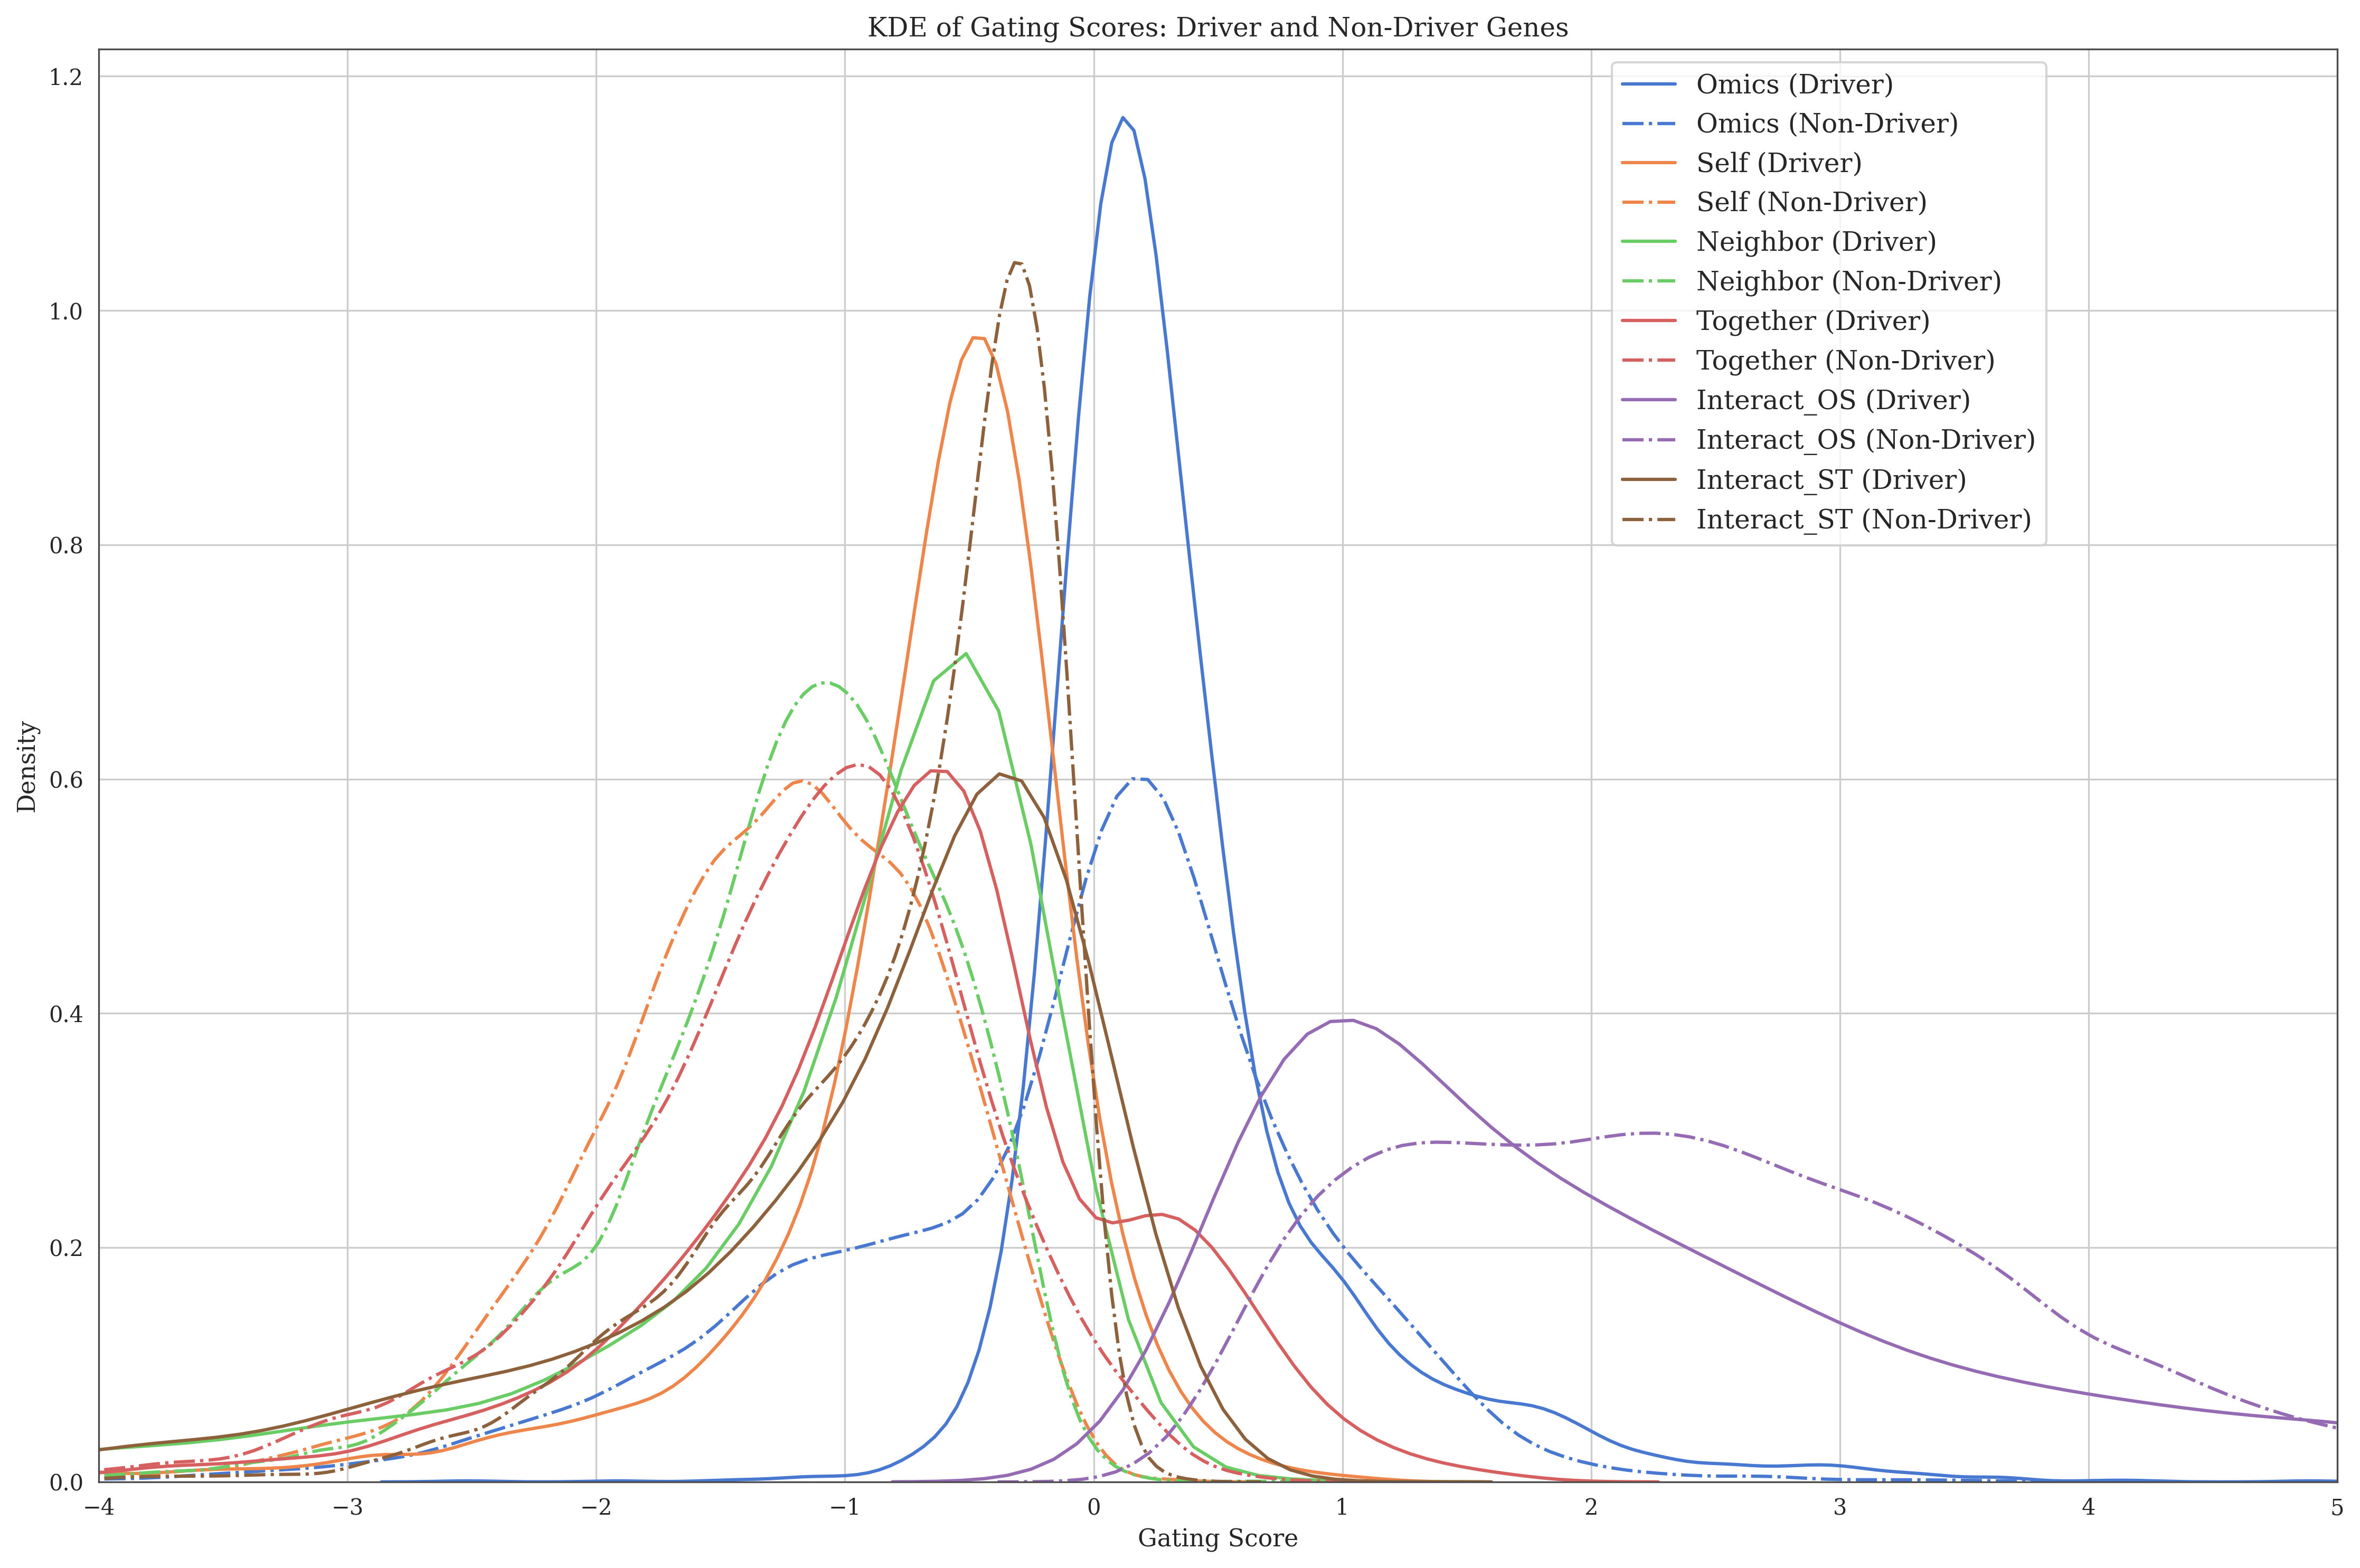

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# 1. 数据准备
# =====================
data = torch.load(r"../data/CPDB/CPDB_new_data.pt")

mask_all = np.logical_or(data.mask, data.mask_te)
Y = np.logical_or(data.y, data.y_te).reshape(-1)

drive_gene = mask_all & (Y == 1)      # 驱动基因掩码
non_drive_gene = mask_all & (Y == 0)  # 非驱动基因掩码

# expert_names = ["label_G", "label_self", "label_neighbor", 
#                 "label_together", "label_concat", "label_satment"]
expert_names = ["Omics", "Self", "Neighbor", "Together", "Interact_OS", "Interact_ST"]
# =====================
# 2. 聚合 gating score
# =====================
all_gating_scores_drive, all_gating_scores_non = [], []

for i in range(1, 6):
    file_path = f"results/gating_analysis/参数分析gating_activation{i}.pt"
    ckpt = torch.load(file_path)
    gating_score = ckpt['gating_score'].numpy()   # [N, num_experts]

    all_gating_scores_drive.append(gating_score[drive_gene])
    all_gating_scores_non.append(gating_score[non_drive_gene])

scores_drive = np.vstack(all_gating_scores_drive)   # [N_drive, num_experts]
scores_non   = np.vstack(all_gating_scores_non)     # [N_non, num_experts]

# =====================
# 3. KDE 可视化（合并到一张图）
# =====================
plt.figure(figsize=(15, 10))

colors = sns.color_palette("muted", len(expert_names))  # 给每个专家分配不同颜色

for i, name in enumerate(expert_names):
    # 驱动基因分布曲线（实线）
    sns.kdeplot(scores_drive[:, i], label=f"{name} (Driver)", color=colors[i], linestyle="-")
    # 非驱动基因分布曲线（虚线）'-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
    sns.kdeplot(scores_non[:, i], label=f"{name} (Non-Driver)", color=colors[i], linestyle="-.")

plt.xlim(-4, 5)
plt.xlabel("Gating Score")
plt.ylabel("Density")
plt.title("KDE of Gating Scores: Driver and Non-Driver Genes")
plt.legend(bbox_to_anchor=(0.67, 1), loc="upper left", fontsize=12)
plt.tight_layout()
# plt.savefig("kde_all_experts.png", dpi=300)
plt.show()


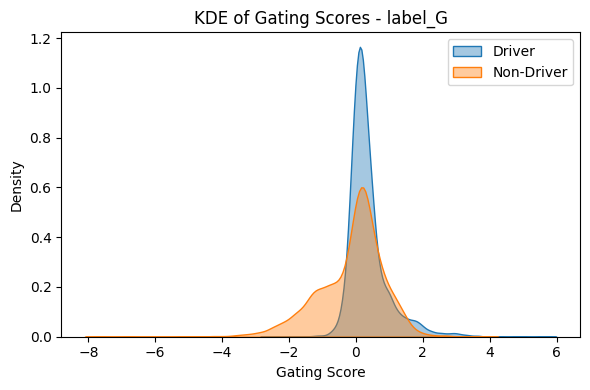

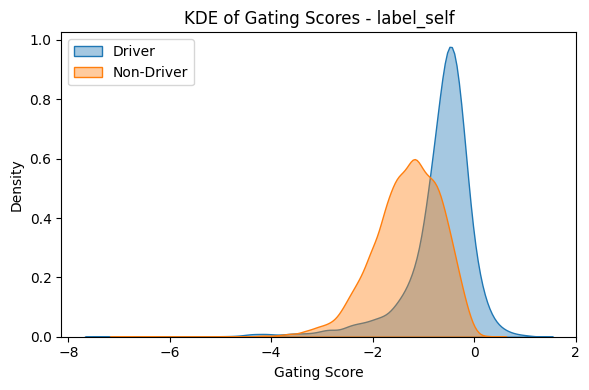

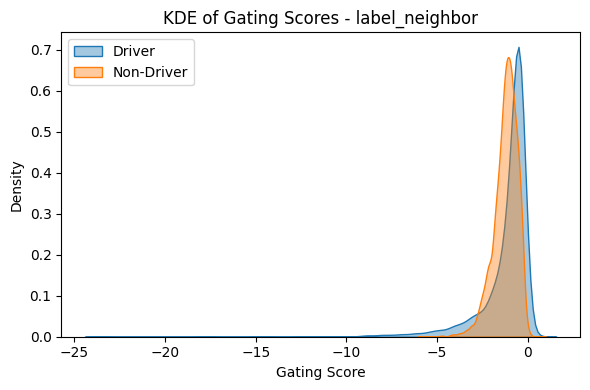

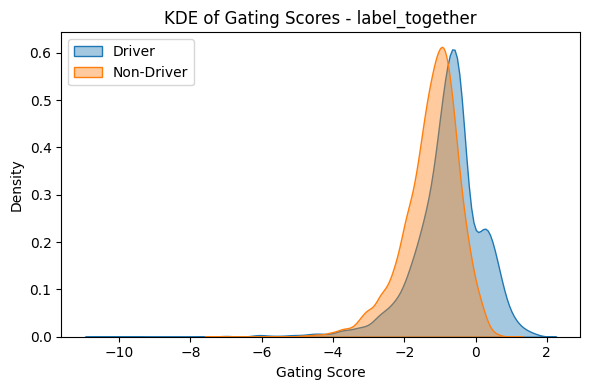

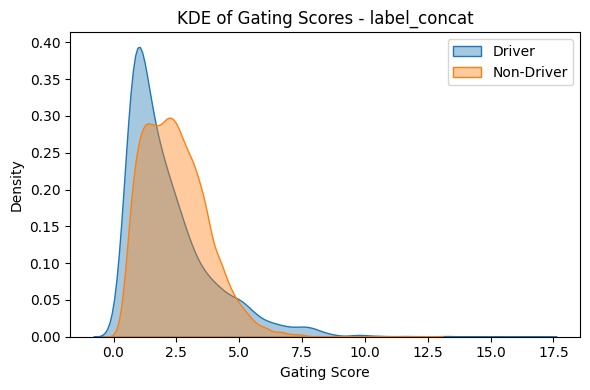

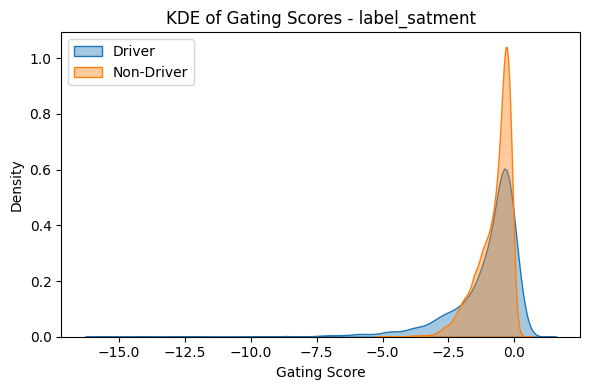

In [100]:
import seaborn as sns

for i, name in enumerate(expert_names):
    plt.figure(figsize=(6,4))
    sns.kdeplot(scores_drive[:, i], label="Driver", fill=True, alpha=0.4)
    sns.kdeplot(scores_non[:, i], label="Non-Driver", fill=True, alpha=0.4)
    plt.xlabel("Gating Score")
    plt.ylabel("Density")
    plt.title(f"KDE of Gating Scores - {name}")
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f"kde_{name}.png", dpi=300)
    plt.show()


In [44]:
import os

# 设置目标目录
folder = 'results/gating_analysis'
# 遍历目录中的所有文件
for filename in os.listdir(folder):
    if filename.startswith('kde'):
        file_path = os.path.join(folder, filename)
        try:
            os.remove(file_path)
            print(f"Deleted: {file_path}")
        except Exception as e:
            print(f"Failed to delete {file_path}: {e}")


Deleted: results/gating_analysis/kde_label_G.png
Deleted: results/gating_analysis/kde_label_concat.png
Deleted: results/gating_analysis/kde_label_together.png
Deleted: results/gating_analysis/kde_all_experts.png
Deleted: results/gating_analysis/kde_label_satment.png
Deleted: results/gating_analysis/kde_label_neighbor.png
Deleted: results/gating_analysis/kde_label_self.png


In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde

# expert_names = ["Omics", "Self", "Neighbor", 
#                 "Together", "Concat", "Satment"]

# 设置采样范围
x_min, x_max = -10, 10
x_vals = np.linspace(x_min, x_max, 500)  # 在 [-10, 10] 区间上取 500 个点

# 保存所有专家的 KDE 数据
records = []

for i, name in enumerate(expert_names):
    # Driver KDE
    kde_drive = gaussian_kde(scores_drive[:, i])
    y_drive = kde_drive(x_vals)
    for xv, yv in zip(x_vals, y_drive):
        records.append({"Expert": name, "Group": "Driver", "X": xv, "Density": yv})
    
    # Non-Driver KDE
    kde_non = gaussian_kde(scores_non[:, i])
    y_non = kde_non(x_vals)
    for xv, yv in zip(x_vals, y_non):
        records.append({"Expert": name, "Group": "Non-Driver", "X": xv, "Density": yv})

# 转换为 DataFrame
df = pd.DataFrame(records)

# 导出为 CSV 文件
df.to_csv("kde_data.csv", index=False)

print("KDE 数据已保存到 kde_data.csv")


KDE 数据已保存到 kde_data.csv


In [19]:
quantiles = [0.1, 0.3, 0.5, 0.7, 0.9]

records = []
for i, name in enumerate(expert_names):
    for group, scores in [("Driver", scores_drive[:, i]), ("Non-Driver", scores_non[:, i])]:
        kde = gaussian_kde(scores)
        xs = np.quantile(scores, quantiles)
        ys = kde(xs)
        for q, xv, yv in zip(quantiles, xs, ys):
            records.append({"Expert": name, "Group": group, "Quantile": q, "X": xv, "Density": yv})

df = pd.DataFrame(records)
df.to_csv("kde_data.csv", index=False)
print(df)


         Expert       Group  Quantile         X   Density
0         Omics      Driver       0.1 -0.150107  0.667935
1         Omics      Driver       0.3  0.053486  1.124068
2         Omics      Driver       0.5  0.208744  1.109439
3         Omics      Driver       0.7  0.423526  0.715905
4         Omics      Driver       0.9  1.065269  0.153583
5         Omics  Non-Driver       0.1 -1.473760  0.142194
6         Omics  Non-Driver       0.3 -0.463537  0.241537
7         Omics  Non-Driver       0.5  0.058844  0.570689
8         Omics  Non-Driver       0.7  0.377013  0.533118
9         Omics  Non-Driver       0.9  0.969915  0.210125
10         Self      Driver       0.1 -1.435203  0.136392
11         Self      Driver       0.3 -0.788968  0.648472
12         Self      Driver       0.5 -0.545029  0.948978
13         Self      Driver       0.7 -0.358558  0.926268
14         Self      Driver       0.9 -0.094901  0.493841
15         Self  Non-Driver       0.1 -2.205292  0.215930
16         Sel

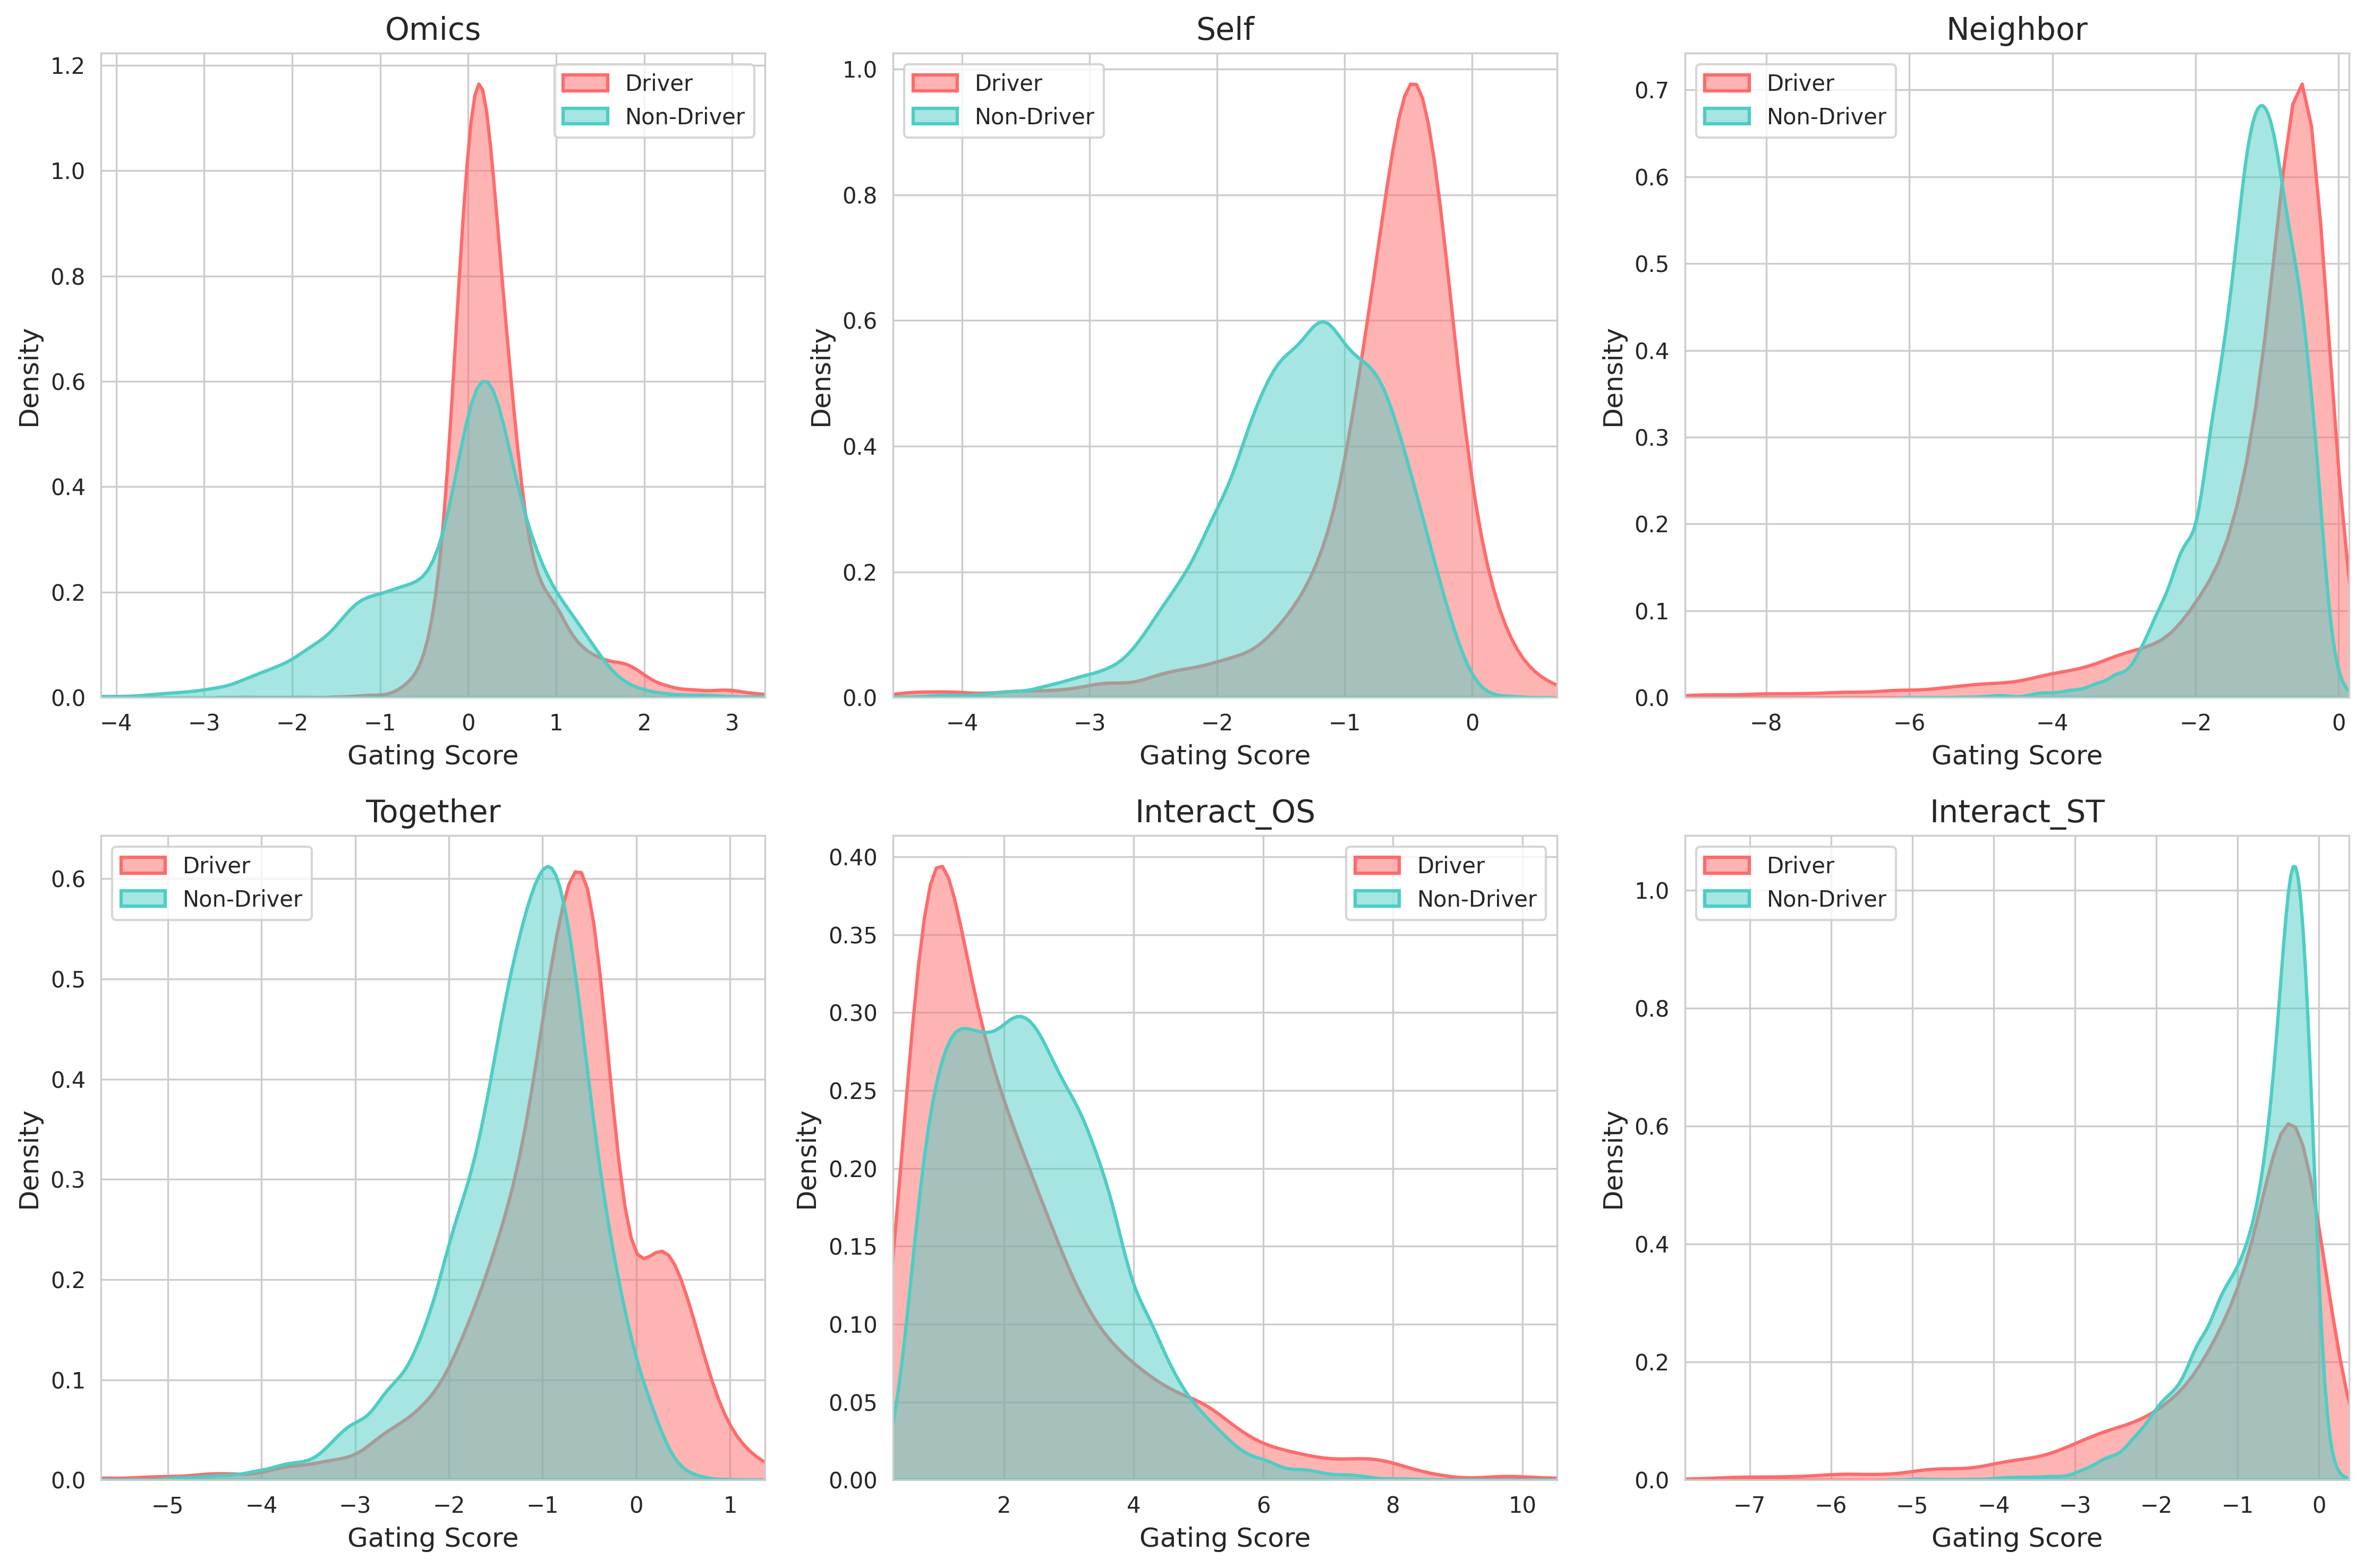

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# 1. 数据准备
# =====================
data = torch.load(r"../data/CPDB/CPDB_new_data.pt")

mask_all = np.logical_or(data.mask, data.mask_te)
Y = np.logical_or(data.y, data.y_te).reshape(-1)

drive_gene = mask_all & (Y == 1)      # 驱动基因掩码
non_drive_gene = mask_all & (Y == 0)  # 非驱动基因掩码

expert_names = ["Omics", "Self", "Neighbor", "Together", "Interact_OS", "Interact_ST"]

# =====================
# 2. 聚合 gating score
# =====================
all_gating_scores_drive, all_gating_scores_non = [], []

for i in range(1, 6):
    file_path = f"results/gating_analysis/参数分析gating_activation{i}.pt"
    ckpt = torch.load(file_path)
    gating_score = ckpt['gating_score'].numpy()   # [N, num_experts]

    all_gating_scores_drive.append(gating_score[drive_gene])
    all_gating_scores_non.append(gating_score[non_drive_gene])

scores_drive = np.vstack(all_gating_scores_drive)   # [N_drive, num_experts]
scores_non   = np.vstack(all_gating_scores_non)     # [N_non, num_experts]

# =====================
# 3. 设置学术论文风格
# =====================
# 设置学术论文风格的参数
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# 使用Seaborn的白色网格风格
sns.set_style("whitegrid")

# =====================
# 4. 创建2×3子图矩阵
# =====================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2行3列
axes = axes.flatten()  # 将二维轴数组展平为一维，便于遍历

# 设置学术论文风格的浅色调
color_drive = '#FF6B6B'  # 柔和的红色
color_non = '#4ECDC4'    # 柔和的蓝色

for i, (ax, name) in enumerate(zip(axes, expert_names)):
    # 计算当前专家数据的95%分位数范围
    combined_scores = np.concatenate([scores_drive[:, i], scores_non[:, i]])
    lower_bound = np.percentile(combined_scores, 0.1)  # 2.5%分位数
    upper_bound = np.percentile(combined_scores, 99.9)  # 97.5%分位数
    
    # 在当前子图绘制KDE - 使用更浅的填充色
    sns.kdeplot(scores_drive[:, i], label="Driver", fill=True, alpha=0.5, 
                color=color_drive, ax=ax, linewidth=1.5)
    sns.kdeplot(scores_non[:, i], label="Non-Driver", fill=True, alpha=0.5, 
                color=color_non, ax=ax, linewidth=1.5)
    
    # 设置子图属性
    ax.set_xlabel("Gating Score")
    ax.set_ylabel("Density")
    ax.set_title(f"{name}")
    
    # 设置x轴范围为数据的95%分位数区间
    ax.set_xlim(lower_bound, upper_bound)
    ax.legend(frameon=True, fancybox=True, framealpha=0.8)

# 调整子图间距
plt.tight_layout()

# 保存或显示图像
# plt.savefig("kde_all_experts_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

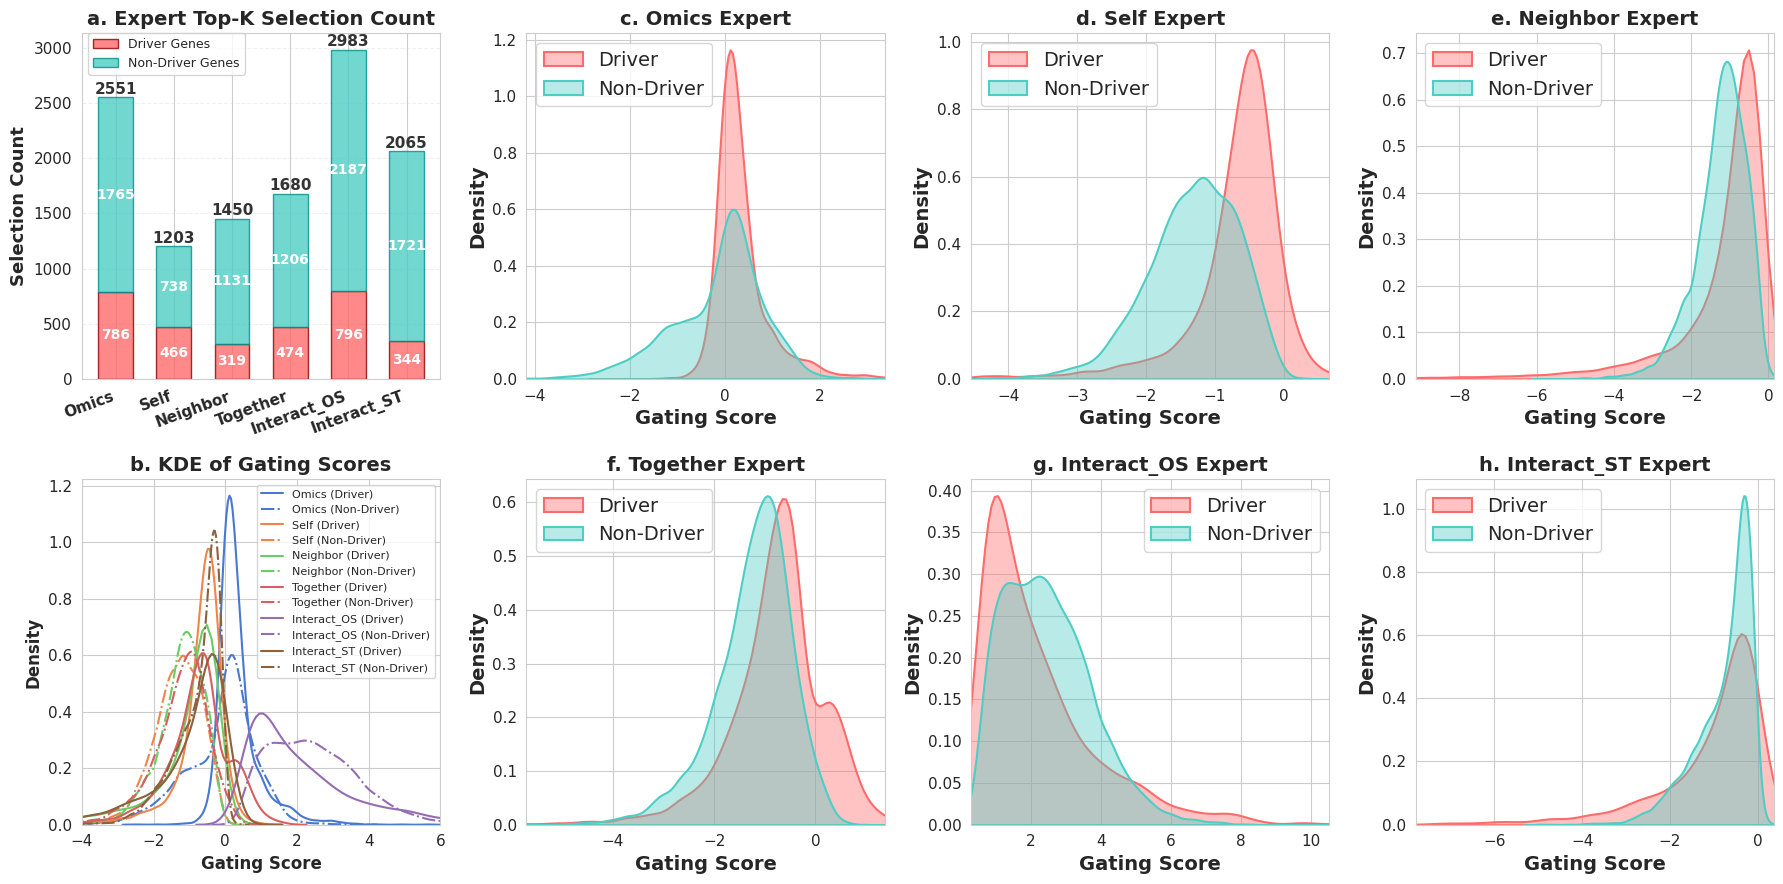

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 注意：本脚本依赖于特定的本地文件路径，请确保在您的环境中文件路径正确。

# =====================
# 1. 数据准备
# =====================
# 假设这些文件路径是正确的，并且数据文件存在于本地
try:
    data = torch.load(r"../data/CPDB/CPDB_new_data.pt")
except FileNotFoundError:
    print("警告：无法加载 CPDB_new_data.pt。正在使用模拟数据进行演示。")
    # 如果文件不存在，创建模拟数据以防止脚本崩溃
    class MockData:
        mask = np.full(100, True)
        mask_te = np.full(100, True)
        y = np.random.choice([0, 1], 100, p=[0.7, 0.3])
        y_te = np.random.choice([0, 1], 100, p=[0.7, 0.3])
    data = MockData()

mask_all = np.logical_or(data.mask, data.mask_te)
Y = np.logical_or(data.y, data.y_te).reshape(-1)

drive_gene = mask_all & (Y == 1)      # 驱动基因掩码
non_drive_gene = mask_all & (Y == 0)  # 非驱动基因掩码

expert_names = ["Omics", "Self", "Neighbor", "Together", "Interact_OS", "Interact_ST"]
num_experts = len(expert_names)

# =====================
# 2. 聚合 gating score (使用模拟数据处理文件不存在情况)
# =====================
all_gating_scores_drive, all_gating_scores_non = [], []
all_drive_counts, all_non_drive_counts = [], []
N_drive = np.sum(drive_gene)
N_non = np.sum(non_drive_gene)

for i in range(1, 6):
    file_path = f"results/gating_analysis/参数分析gating_activation{i}.pt"
    try:
        ckpt = torch.load(file_path)
        gating_score = ckpt['gating_score'].numpy()   # [N, num_experts]
        topk_indices = ckpt['topk_indices'].numpy()  # [N, k]
    except FileNotFoundError:
        print(f"警告：无法加载 {file_path}。正在使用模拟数据。")
        # 模拟数据
        gating_score = np.random.normal(loc=i, scale=1.5, size=(len(Y), num_experts))
        topk_indices = np.random.randint(0, num_experts, size=(len(Y), 2))
    
    # 获取top-k选择计数
    drive_counts = np.zeros(num_experts)
    non_drive_counts = np.zeros(num_experts)
    
    # 统计每个专家被选中的次数
    for idx in range(num_experts):
        drive_counts[idx] = np.sum(topk_indices[drive_gene] == idx)
        non_drive_counts[idx] = np.sum(topk_indices[non_drive_gene] == idx)
    
    all_drive_counts.append(drive_counts)
    all_non_drive_counts.append(non_drive_counts)
    all_gating_scores_drive.append(gating_score[drive_gene])
    all_gating_scores_non.append(gating_score[non_drive_gene])

# 检查是否有聚合分数，如果没有，则创建纯模拟数据以避免崩溃
if not all_gating_scores_drive or not all_gating_scores_non:
    # 再次创建纯随机数据
    scores_drive = np.random.normal(loc=1, scale=1.5, size=(N_drive * 5, num_experts))
    scores_non = np.random.normal(loc=0, scale=1.5, size=(N_non * 5, num_experts))
    all_drive_counts = [np.random.randint(50, 200, num_experts) for _ in range(5)]
    all_non_drive_counts = [np.random.randint(100, 400, num_experts) for _ in range(5)]
    print("注意：由于所有文件加载失败，图表将使用纯随机数据，仅用于结构演示。")
else:
    scores_drive = np.vstack(all_gating_scores_drive)   # [N_drive, num_experts]
    scores_non   = np.vstack(all_gating_scores_non)     # [N_non, num_experts]

# 计算平均结果
all_drive_counts = np.array(all_drive_counts)  # [5, 6]
all_non_drive_counts = np.array(all_non_drive_counts)  # [5, 6]
avg_drive_counts = np.mean(all_drive_counts, axis=0)  # 驱动基因平均选择次数
avg_non_drive_counts = np.mean(all_non_drive_counts, axis=0)  # 非驱动基因平均选择次数


# =====================
# 3. 设置学术论文风格 (增大字体)
# =====================
plt.rcParams.update({
    'font.size': 12,        # 基础字体大小从 10 增加到 12
    'font.family': 'serif',
    'axes.labelsize': 12,   # 轴标签字体大小从 10 增加到 12
    'axes.titlesize': 14,   # 标题字体大小从 12 增加到 14
    'legend.fontsize': 11,  # 图例字体大小从 9 增加到 11
    'xtick.labelsize': 11,  # X轴刻度标签字体大小从 9 增加到 11
    'ytick.labelsize': 11,  # Y轴刻度标签字体大小从 9 增加到 11
    'figure.titlesize': 16, # 整体图的标题
})

sns.set_style("whitegrid")

# =====================
# 4. 创建2×4子图矩阵
# =====================
fig, axes = plt.subplots(2, 4, figsize=(18, 9))  # 稍微增大整体图的大小

# 设置学术论文风格的浅色调
color_drive = '#FF6B6B'  # 柔和的红色
color_non = '#4ECDC4'    # 柔和的蓝绿色

# =====================
# 5. 第一个子图：Top-k 专家选择频率（堆叠柱状图）
# =====================
ax1 = axes[0, 0]
x = np.arange(len(expert_names))
width = 0.6

bars_drive = ax1.bar(x, avg_drive_counts, width=width, color=color_drive, 
                     edgecolor='darkred', linewidth=1, label='Driver Genes', alpha=0.8)
bars_non_drive = ax1.bar(x, avg_non_drive_counts, width=width, bottom=avg_drive_counts, 
                         color=color_non, edgecolor='darkcyan', linewidth=1, 
                         label='Non-Driver Genes', alpha=0.8)

# 在柱子上显示总频数
for i, (drive, non_drive) in enumerate(zip(avg_drive_counts, avg_non_drive_counts)):
    total = drive + non_drive
    ax1.text(x[i], total + 5, f"{int(round(total))}", ha="center", va="bottom", 
             fontsize=11, color='#333333', fontweight='bold') # 字体增大
    
    # 添加部分标签
    # 驱动基因标签（底部）
    if drive > 0:
        ax1.text(x[i], drive/2, f"{int(round(drive))}", ha="center", va="center", 
                 fontsize=10, fontweight='bold', color='white') # 字体增大
    # 非驱动基因标签（顶部）
    if non_drive > 0:
        ax1.text(x[i], drive + non_drive/2, f"{int(round(non_drive))}", ha="center", 
                 va="center", fontsize=10, fontweight='bold', color='white') # 字体增大

ax1.set_xticks(x)
ax1.set_xticklabels(expert_names, fontsize=11, rotation=20, ha='right', fontweight='bold') # 字体增大
ax1.set_ylabel("Selection Count", fontweight='bold', fontsize=13) # 字体增大
ax1.set_title("a. Expert Top-K Selection Count", fontweight='bold', fontsize=14) # 字体增大
ax1.legend(loc='upper left', fontsize=9, bbox_to_anchor=(0, 1.02))
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# =====================
# 6. 第二个子图：合并KDE图（图例移到右上角）
# =====================
ax2 = axes[1, 0]
colors_kde = sns.color_palette("muted", len(expert_names))

for i, name in enumerate(expert_names):
    # 驱动基因分布曲线（实线）
    sns.kdeplot(scores_drive[:, i], label=f"{name} (Driver)", color=colors_kde[i], 
                linestyle="-", ax=ax2)
    # 非驱动基因分布曲线（虚线）
    sns.kdeplot(scores_non[:, i], label=f"{name} (Non-Driver)", color=colors_kde[i], 
                linestyle="-.", ax=ax2)

# 确保x轴范围合理，避免图被压扁
# combined_all = np.concatenate([scores_drive.flatten(), scores_non.flatten()])
# if combined_all.size > 0:
#     min_val, max_val = combined_all.min(), combined_all.max()
#     x_lim_min = min_val - (max_val - min_val) * 0.1
#     x_lim_max = max_val + (max_val - min_val) * 0.1
#     ax2.set_xlim(x_lim_min, x_lim_max)
# else:
ax2.set_xlim(-4, 6) # 保留原始默认值

ax2.set_xlabel("Gating Score", fontweight='bold')
ax2.set_ylabel("Density", fontweight='bold')
ax2.set_title("b. KDE of Gating Scores", fontweight='bold', fontsize=14) # 字体增大
# 图例移到右上角
ax2.legend(loc='upper right', fontsize=8) # 字体增大

# =====================
# 7. 其余6个子图：单个专家的KDE图
# =====================
kde_axes = [axes[0, 1], axes[0, 2], axes[0, 3], 
            axes[1, 1], axes[1, 2], axes[1, 3]]
wordranges = ['c', 'd', 'e', 'f', 'g', 'h']
for i, (ax, name) in enumerate(zip(kde_axes, expert_names)):
    # 计算当前专家数据的99%分位数范围
    combined_scores = np.concatenate([scores_drive[:, i], scores_non[:, i]])
    
    if combined_scores.size > 0:
        # 排除极值，获取99.9%的数据范围
        lower_bound = np.percentile(combined_scores, 0.1)
        upper_bound = np.percentile(combined_scores, 99.90)
    else:
        lower_bound, upper_bound = -4, 6

    # 在当前子图绘制KDE
    sns.kdeplot(scores_drive[:, i], label="Driver", fill=True, alpha=0.4, 
                color=color_drive, ax=ax, linewidth=1.5)
    sns.kdeplot(scores_non[:, i], label="Non-Driver", fill=True, alpha=0.4, 
                color=color_non, ax=ax, linewidth=1.5)
    
    # 设置子图属性
    ax.set_xlabel("Gating Score", fontsize=14, fontweight='bold') # 字体增大
    ax.set_ylabel("Density", fontsize=14, fontweight='bold')     # 字体增大
    # ax.set_title(f"{name} Expert", fontweight='bold', fontsize=14) # 字体增大
    ax.set_title(f"{wordranges[i]}. {name} Expert", fontweight='bold', fontsize=14) # 字体增大
    
    # 设置x轴范围为数据的分位数区间
    ax.set_xlim(lower_bound, upper_bound)
    ax.legend(frameon=True, fancybox=True, framealpha=0.8, fontsize=14) # 字体增大

# =====================
# 8. 调整布局并显示
# =====================
# 自动调整子图参数，使之填充整个图像区域
plt.tight_layout() 

# 保存或显示图像
plt.savefig("combined_analysis_2x4_enhanced_font.svg", bbox_inches='tight')
plt.savefig("gate_analysis", dpi=300, bbox_inches='tight')
plt.show()

In [1]:
import torch
import numpy as np

# =====================
# 查询任意基因的 Gating Score 权重
# =====================

def query_gene_weights(gene_name, data_path="../data/CPDB/CPDB_new_data.pt", 
                       gating_dir="results/gating_analysis"):
    """
    查询指定基因的 Gating Score 权重。
    
    参数:
        gene_name: 基因名称 (如 "TP53", "EGFR", "BRCA1" 等)
        data_path: CPDB 数据文件路径
        gating_dir: gating_activation 文件所在目录
    """
    # 加载数据
    data = torch.load(data_path)
    expert_names = ["Omics", "Self", "Neighbor", "Together", "Interact_OS", "Interact_ST"]
    
    # 查找基因
    indices = []
    for idx, name in enumerate(data.node_names):
        if name[1] == gene_name:
            indices.append(idx)
    
    if not indices:
        print(f"未找到基因 '{gene_name}'！")
        print(f"提示：基因名区分大小写，如 TP53、EGFR、BRCA1 等")
        return
    
    print(f"找到 {len(indices)} 个与 '{gene_name}' 相关的基因:")
    for idx in indices:
        print(f"  索引 {idx}: {data.node_names[idx]}")
    
    # 加载所有 gating activation 文件
    all_scores = []
    all_topk = []
    
    for i in range(1, 6):
        file_path = f"{gating_dir}/参数分析gating_activation{i}.pt"
        ckpt = torch.load(file_path)
        gating_score = ckpt['gating_score'].numpy()   # [N, num_experts]
        topk_indices = ckpt['topk_indices'].numpy()    # [N, k]
        all_scores.append(gating_score)
        all_topk.append(topk_indices)
    
    avg_scores_over_runs = np.mean(all_scores, axis=0)  # [N, num_experts]
    
    # 打印每个匹配基因的结果
    for idx in indices:
        gene_full = data.node_names[idx]
        label = data.y[idx].item()
        is_driver = "驱动基因 (Driver)" if label == 1 else "非驱动基因 (Non-Driver)"
        
        print(f"\n{'='*60}")
        print(f"基因: {gene_full[1]} (Ensembl: {gene_full[0]})  |  索引: {idx}  |  {is_driver}")
        print(f"{'='*60}")
        
        # 打印每次实验的 gating score
        print(f"\n{'实验':>5} | ", end="")
        for name in expert_names:
            print(f"{name:>13}", end="")
        print()
        print("-" * 90)
        
        for run_i in range(5):
            score = all_scores[run_i][idx]
            topk = all_topk[run_i][idx]
            print(f"  {run_i+1:>2}  | ", end="")
            for s in score:
                print(f"{s:>13.4f}", end="")
            topk_names = [expert_names[k] for k in topk]
            print(f"  → Top-K: {topk_names}")
        
        # 平均结果
        avg_score = avg_scores_over_runs[idx]
        print("-" * 90)
        print(f" {'平均':>4} | ", end="")
        for s in avg_score:
            print(f"{s:>13.4f}", end="")
        print()
        
        # 模型保存的 Top-K 统计
        model_k = all_topk[0].shape[1]
        print(f"\n▶  模型 Top-K 选中统计 (k={model_k}):")
        all_topk_for_gene = np.concatenate([all_topk[r][idx] for r in range(5)])
        for e_i, name in enumerate(expert_names):
            count = np.sum(all_topk_for_gene == e_i)
            bar = "█" * count + "░" * (5 - count)
            print(f"   {name:>15}: {count}/5 {bar}")
        
        # 按门控分数排序显示 Top-5 专家
        print(f"\n▶  按 Gating Score 排序 Top-5:")
        # 用平均分数排序
        avg_score = avg_scores_over_runs[idx]
        sorted_indices = np.argsort(avg_score)[::-1]  # 从高到低排序
        print(f"   {'排名':>4} | {'Expert':>15} | {'Avg Score':>10} | {'实验1':>8} {'实验2':>8} {'实验3':>8} {'实验4':>8} {'实验5':>8}")
        print("   " + "-" * 75)
        for rank, ei in enumerate(sorted_indices[:5], 1):
            scores_str = " ".join(f"{all_scores[r][idx][ei]:>8.4f}" for r in range(5))
            print(f"   {rank:>4} | {expert_names[ei]:>15} | {avg_score[ei]:>10.4f} | {scores_str}")
        
        # 特征向量统计
        x_vec = data.x[idx].numpy()
        print(f"\n▶  节点特征 (x) 统计: 维度={len(x_vec)}, "
              f"非零={np.count_nonzero(x_vec)}/{len(x_vec)}, "
              f"均值={x_vec.mean():.4f}, 标准差={x_vec.std():.4f}")
    
    return avg_scores_over_runs[indices] if len(indices) == 1 else avg_scores_over_runs[indices]


# =====================
# 使用示例
# =====================

# 在这里修改基因名来查询不同基因的权重
GENE_NAME = "TP53"   # ← 修改这里来查询其他基因，如 "EGFR", "BRCA1", "MYC", "KRAS" 等

query_gene_weights(GENE_NAME)


site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


找到 1 个与 'TP53' 相关的基因:
  索引 89: ['ENSG00000141510' 'TP53']

基因: TP53 (Ensembl: ENSG00000141510)  |  索引: 89  |  非驱动基因 (Non-Driver)

   实验 |         Omics         Self     Neighbor     Together  Interact_OS  Interact_ST
------------------------------------------------------------------------------------------
   1  |        0.2458      -7.2698      -9.6067     -10.3929      16.6269     -12.1606  → Top-K: ['Interact_OS', 'Omics', 'Self', 'Neighbor']
   2  |        1.5801      -2.4068      -4.1495      -4.7829      13.3659      -7.0786  → Top-K: ['Interact_OS', 'Omics', 'Self', 'Neighbor']
   3  |        5.6452      -1.4882      -0.5935       1.5627      13.2690      -3.6771  → Top-K: ['Interact_OS', 'Omics', 'Together', 'Neighbor']
   4  |        1.5102      -1.4279     -23.5590      -9.6892      11.5031     -15.5191  → Top-K: ['Interact_OS', 'Omics', 'Self', 'Together']
   5  |        2.5681      -2.2810      -7.7694      -5.5218       5.1623       0.1546  → Top-K: ['Interact_OS', 'Omics'

array([[ 2.3099039, -2.9747195, -9.135588 , -5.7648096, 11.985434 ,
        -7.65616  ]], dtype=float32)